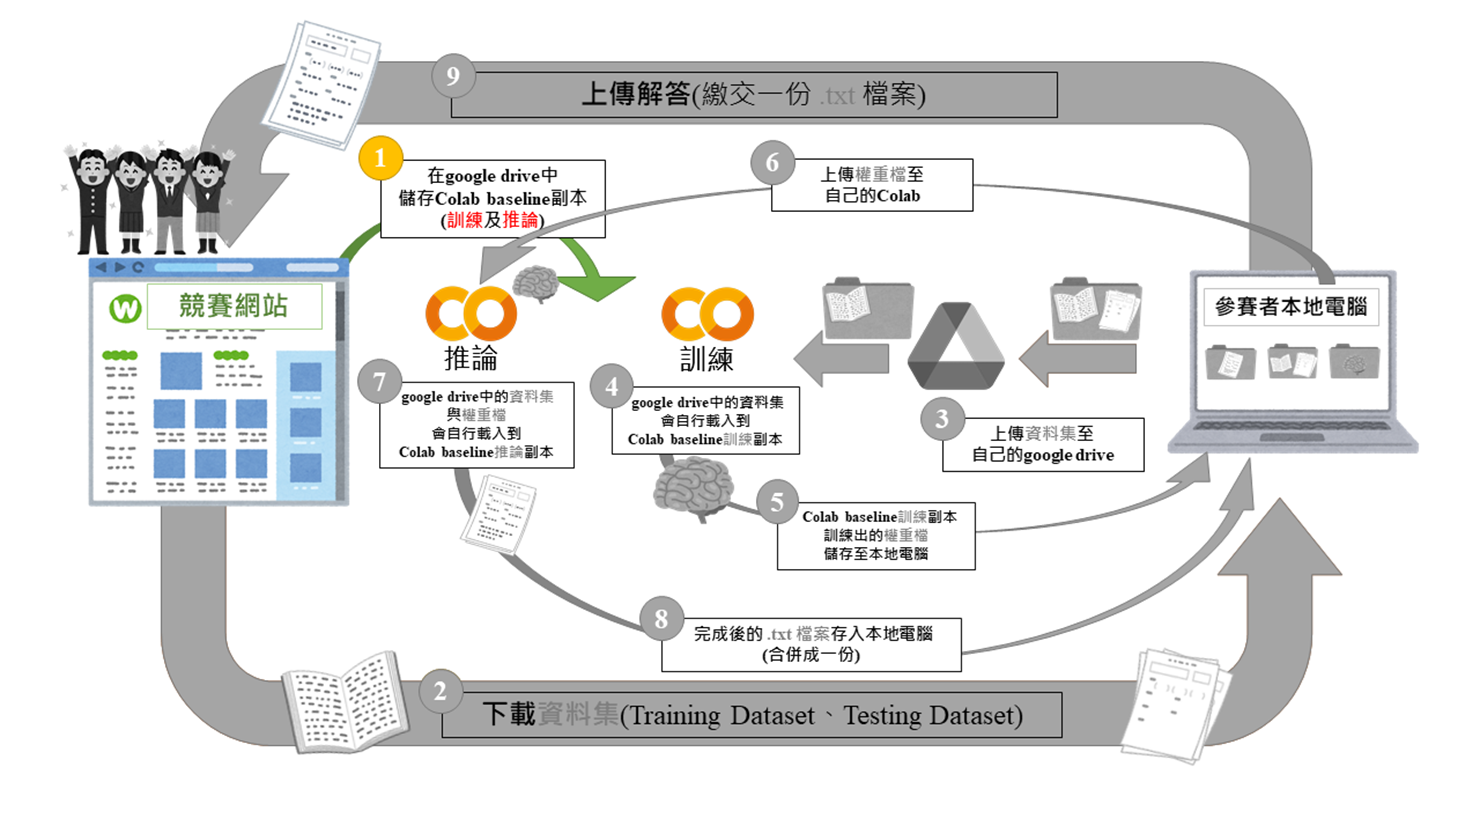

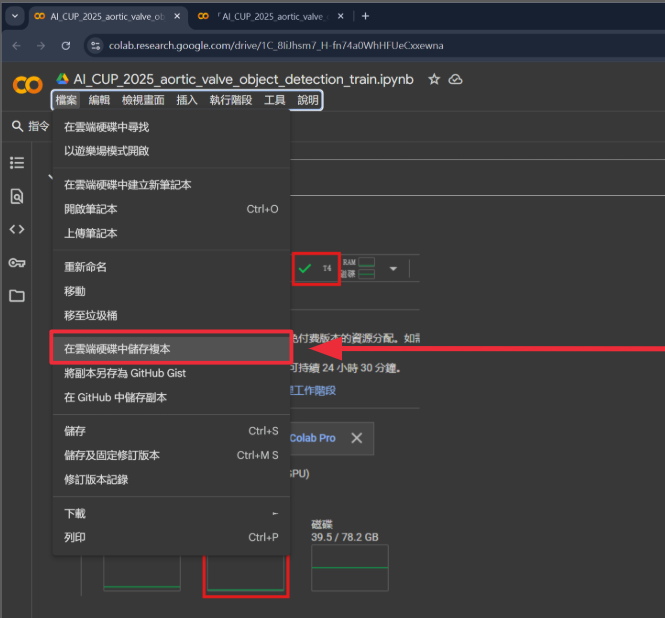

#### 1.設置環境

從畫面右上角確認有使用到GPU

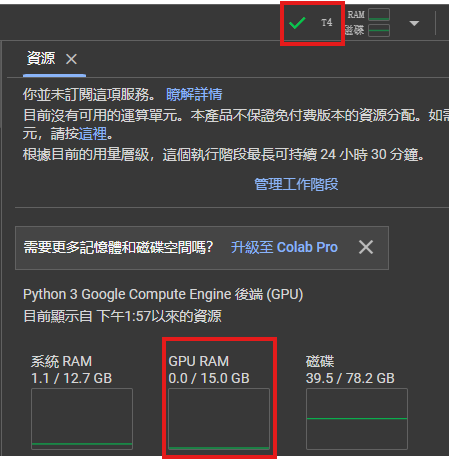

如果沒連到的話請切換到GPU

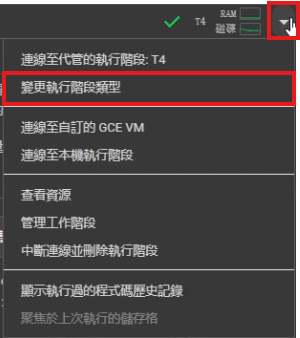
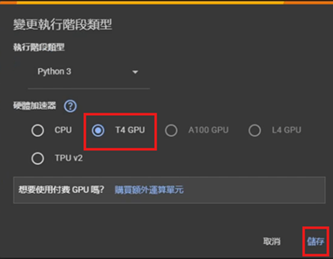

Colab區塊左方有綠色勾代表執行完成且成功 image.png


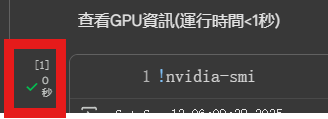

區塊左方有圈在轉代表執行中 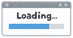

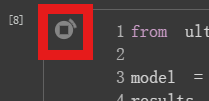

區塊左方有紅色驚嘆號代表運行錯誤 image.png

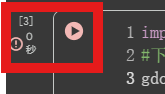

#=====================================================

#BLOCK 1

#查看GPU資訊(運行時間<1秒) image.png

#=====================================================

In [ ]:
!nvidia-smi

Sun Nov 30 14:25:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#=====================================================

#BLOCK 2

#確保不會出現編碼錯誤(運行時間<1秒) image.png

#=====================================================

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

#=====================================================

#BLOCK 3

#下載YOLOv12套件(運行時間12秒) image.png

#=====================================================

In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.1/112.6 GB disk)


 #### 2. 上傳資料集

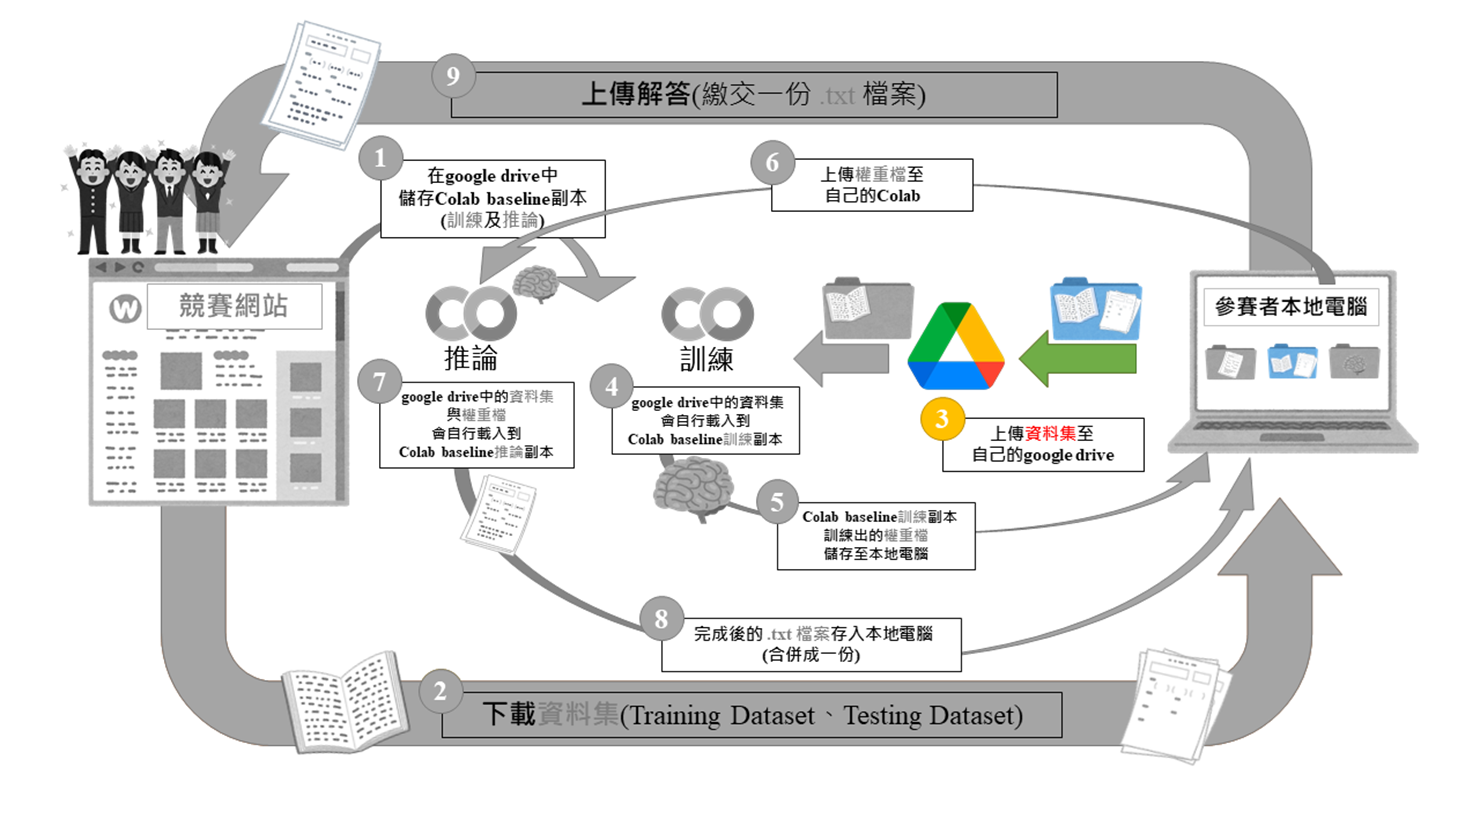

將testing_image.zip上傳至個人的Google雲端硬碟

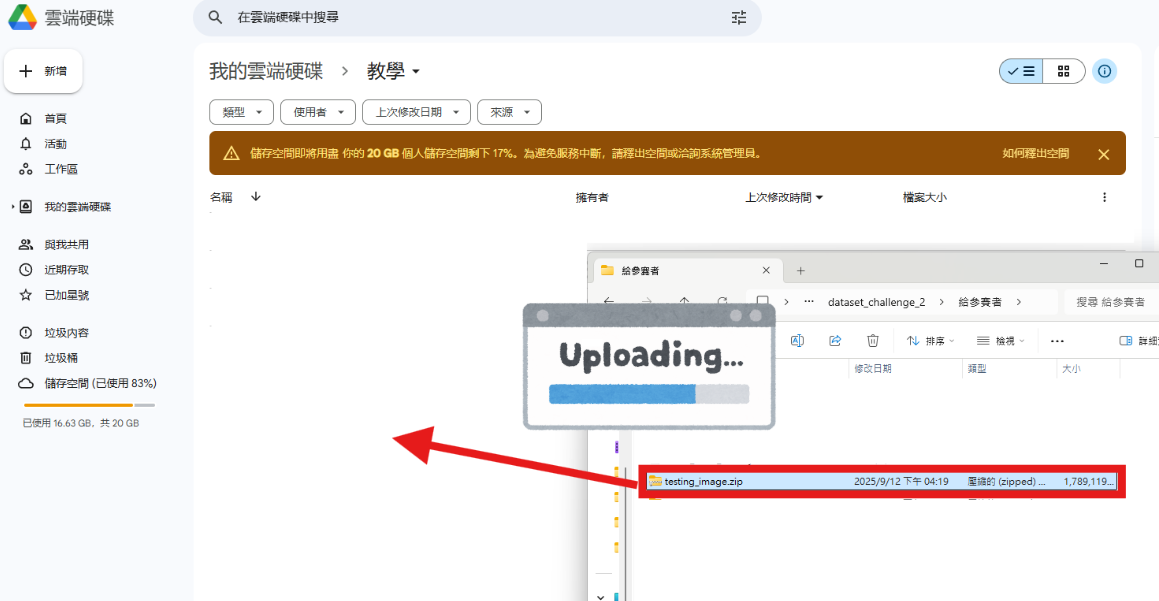

更改testing_image.zip檔案權限 image.png
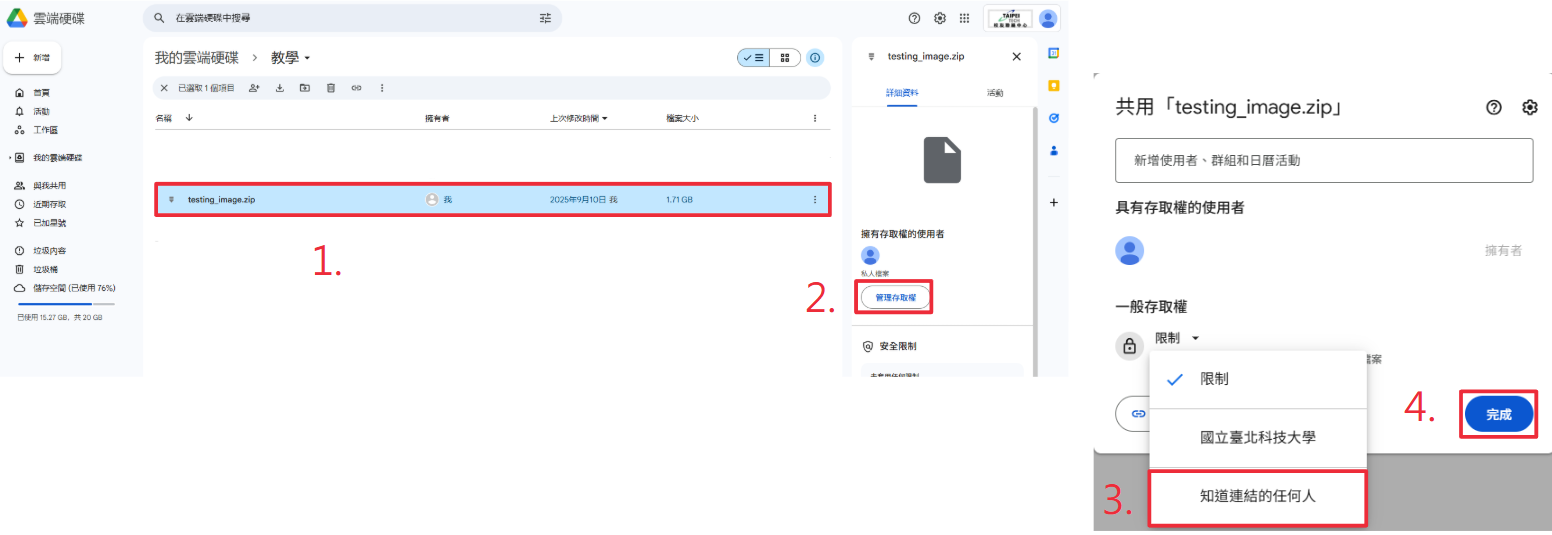

取得雲端資料下載連結(下方程式需要用到)

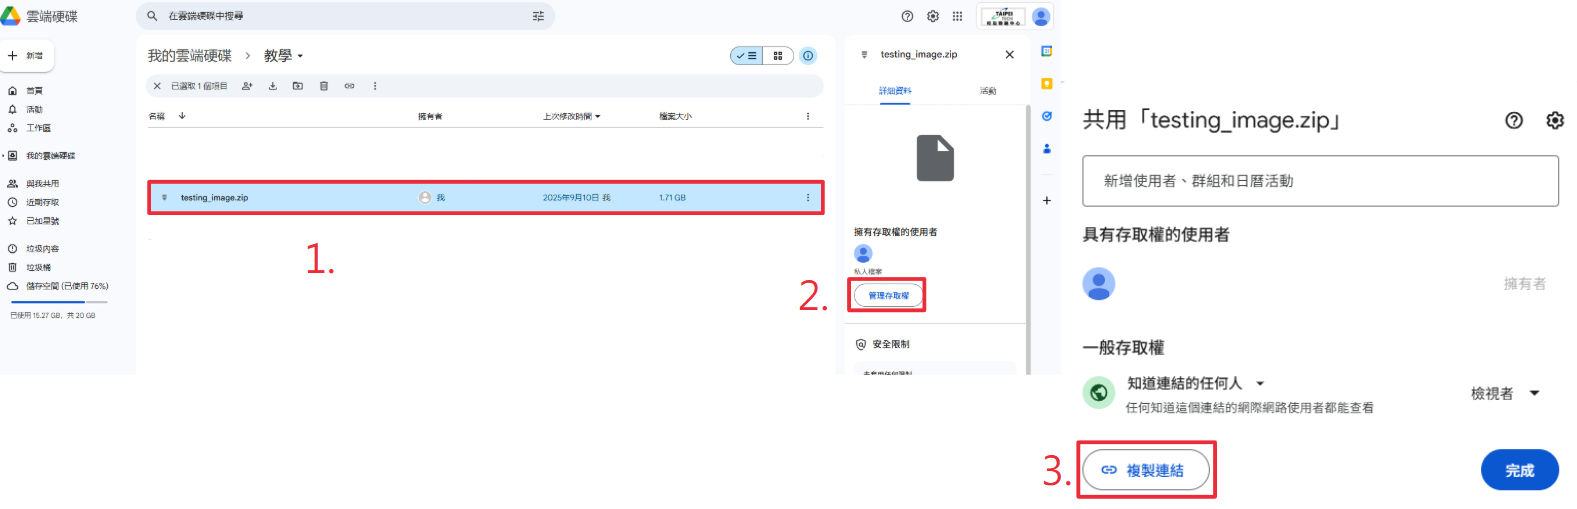

將剛剛取得的網址透過下方網址轉換成直接下載的格式


https://sites.google.com/view/twdrivefromdownload/%E7%B9%81%E9%AB%94%E4%B8%AD%E6%96%87traditional-chinese?authuser=0


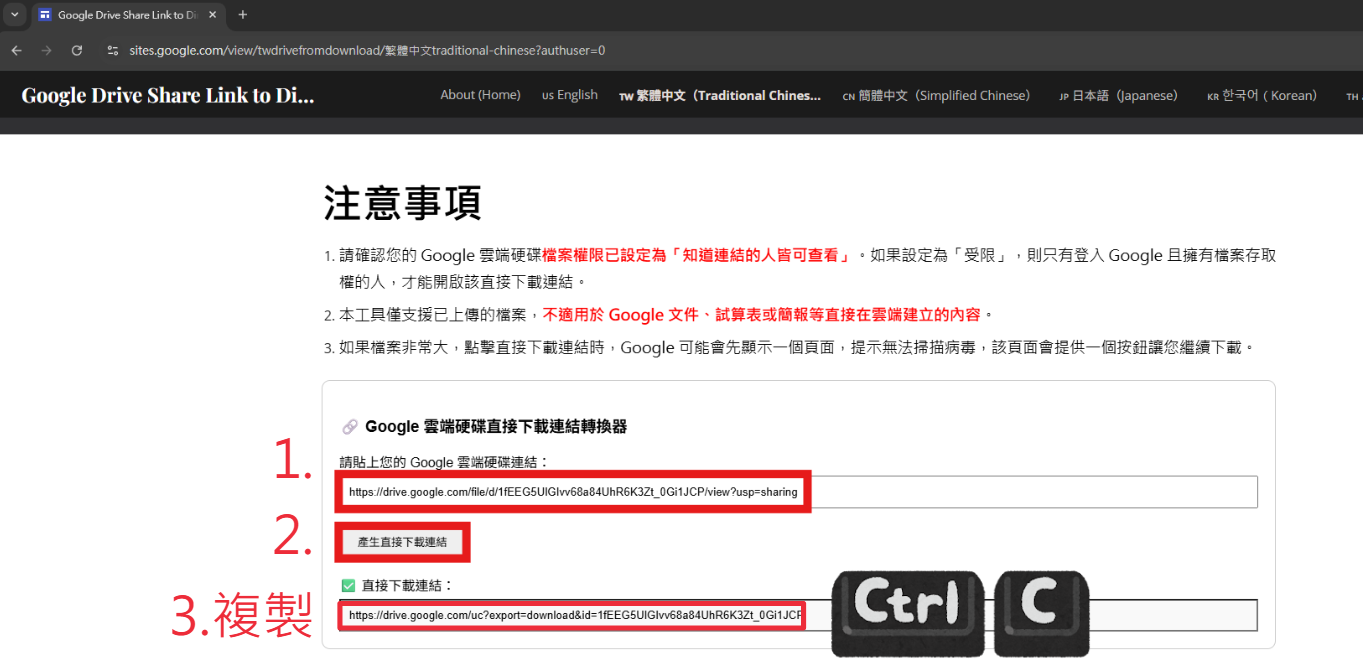

#=====================================================

#BLOCK 4

#透過上面方法更改下方程式測試資料集的網址(執行時間<1分鐘) image.png


 *請自行上傳雲端替換成自己的連結，此範例連結雖然與最初競賽資料集相同，但不保證會更新且隨時有可能會刪除!!!

#=====================================================

In [ ]:
#下載資料集
import gdown
import os
!mkdir ./datasets
!mkdir ./datasets/test
gdown.download("https://drive.google.com/uc?export=download&id=1-PnvYtmlfhb39iV-Y09I8j5GHaO","/content/datasets/testing.zip")
!unzip '/content/datasets/testing' -d '/content/datasets/test/tmp'

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1-PnvYtmlfhb39iV-Y09I7O6fY8j5GHaO
From (redirected): https://drive.google.com/uc?export=download&id=1-PnvYtmlfhb39iV-Y09I7O6fY8j5GHaO&confirm=t&uuid=898d10d4-7a55-4dea-bad1-ed7cec974fa1
To: /content/datasets/testing.zip
100%|██████████| 1.83G/1.83G [00:25<00:00, 72.8MB/s]


串流輸出內容已截斷至最後 5000 行。
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0078.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0079.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0080.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0081.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0082.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0083.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0084.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0085.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0086.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0087.png  
  inflating: /content/datasets/test/tmp/testing_image/patient0086/patient0086_0088.png  


因為本競賽Testing資料集有16620張圖片，如果全部一起預測Colab的RAM會不足，所以將Testing圖片分成兩次做預測

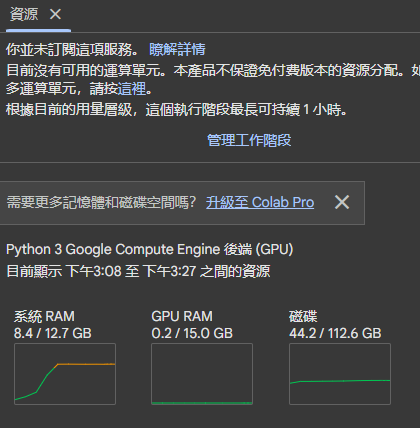

#=====================================================

#BLOCK 5

#移動圖片位置(透過下方程式)


#一半的圖片移至imges1資料夾，另一半移至imges2資料夾

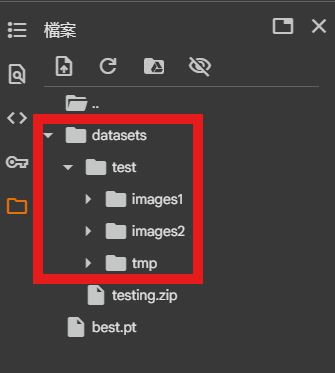

#=====================================================

In [ ]:
import os
import shutil

base_root = "/content/datasets/test/tmp"
dst_root1 = "/content/datasets/test/images1"
dst_root2 = "/content/datasets/test/images2"

os.makedirs(dst_root1, exist_ok=True)
os.makedirs(dst_root2, exist_ok=True)

# 自動找到第一個「直屬子資料夾含 patient*」的目錄
patient_root = base_root
for dirpath, dirnames, _ in os.walk(base_root):
    if any(d.lower().startswith("patient") for d in dirnames):
        patient_root = dirpath
        break

# 收集所有圖片路徑（只看直屬的 patient 資料夾）
all_files = []
for patient_folder in os.listdir(patient_root):
    patient_path = os.path.join(patient_root, patient_folder)
    if os.path.isdir(patient_path) and patient_folder.lower().startswith("patient"):
        for fname in os.listdir(patient_path):
            if fname.lower().endswith(".png"):
                all_files.append(os.path.join(patient_path, fname))

# 按名稱排序並對半移動
all_files.sort()
half = len(all_files) // 2

for f in all_files[:half]:
    shutil.move(f, os.path.join(dst_root1, os.path.basename(f)))

for f in all_files[half:]:
    shutil.move(f, os.path.join(dst_root2, os.path.basename(f)))

print(f"來源根目錄：{patient_root}")
print(f"完成移動！總共 {len(all_files)} 張，前半 {half} 張到 images1，後半 {len(all_files)-half} 張到 images2")


來源根目錄：/content/datasets/test/tmp/testing_image
完成移動！總共 16620 張，前半 8310 張到 images1，後半 8310 張到 images2


In [ ]:
print('測試集圖片數量 : ',len(os.listdir("./datasets/test/images1"))+len(os.listdir("./datasets/test/images2")))

測試集圖片數量 :  16620


#### 3. Predict

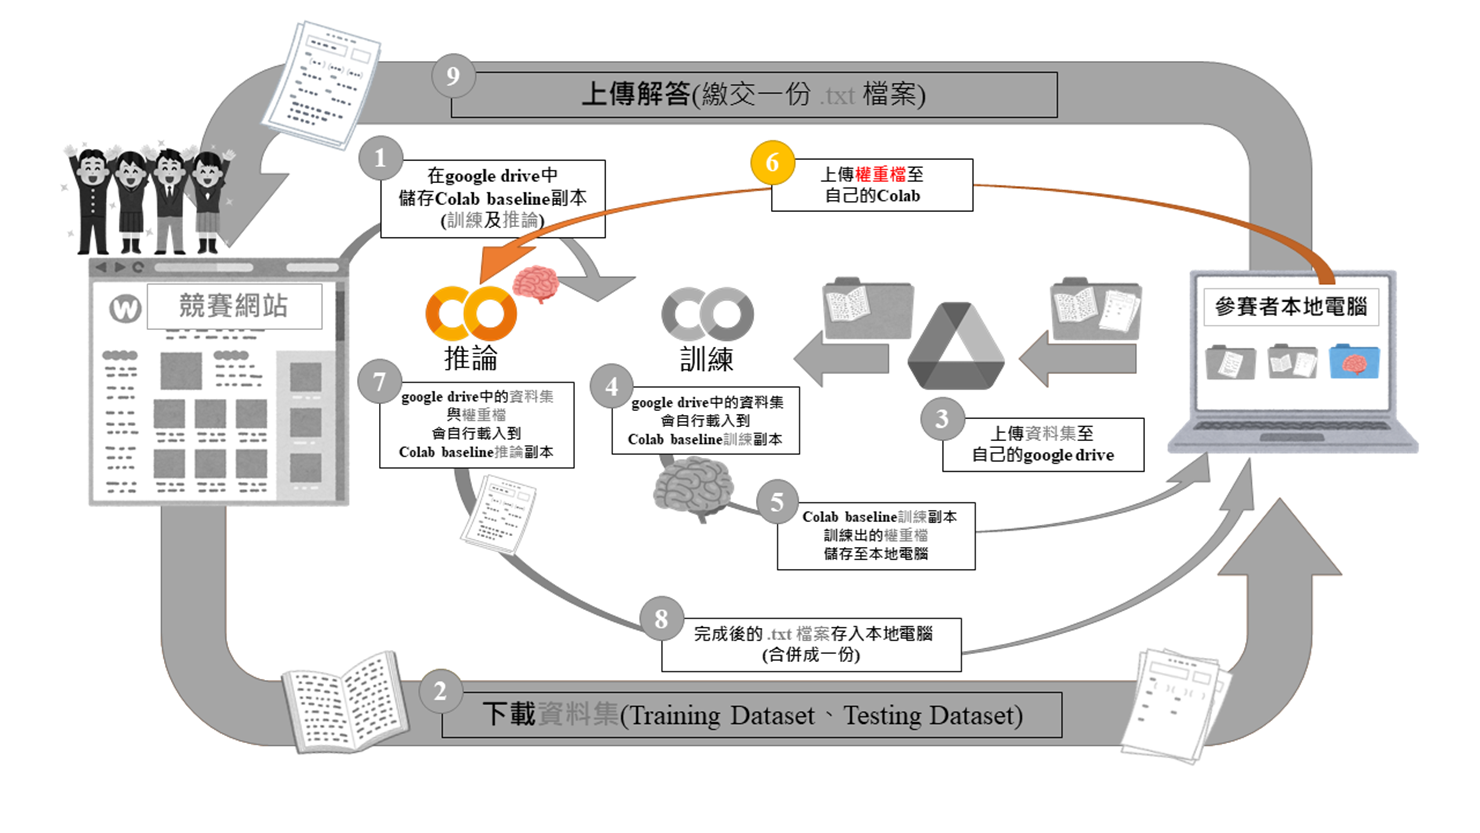

#=====================================================

#BLOCK 6

#下載競賽主辦方模型權重檔(此權重檔為baseline提供的模型，參賽者可替換成自行訓練的模型檔)

#=====================================================

In [ ]:
#自行上傳權重檔請註解掉下方程式
gdown.download("https://drive.google.com/uc?export=download&id=1cyV2eWcJYJcvWnc56L_zp1Lky3p9Yign","/content/best.pt")

KeyboardInterrupt: 

#使用自行訓練模型可透過拖移方式上傳至Colab

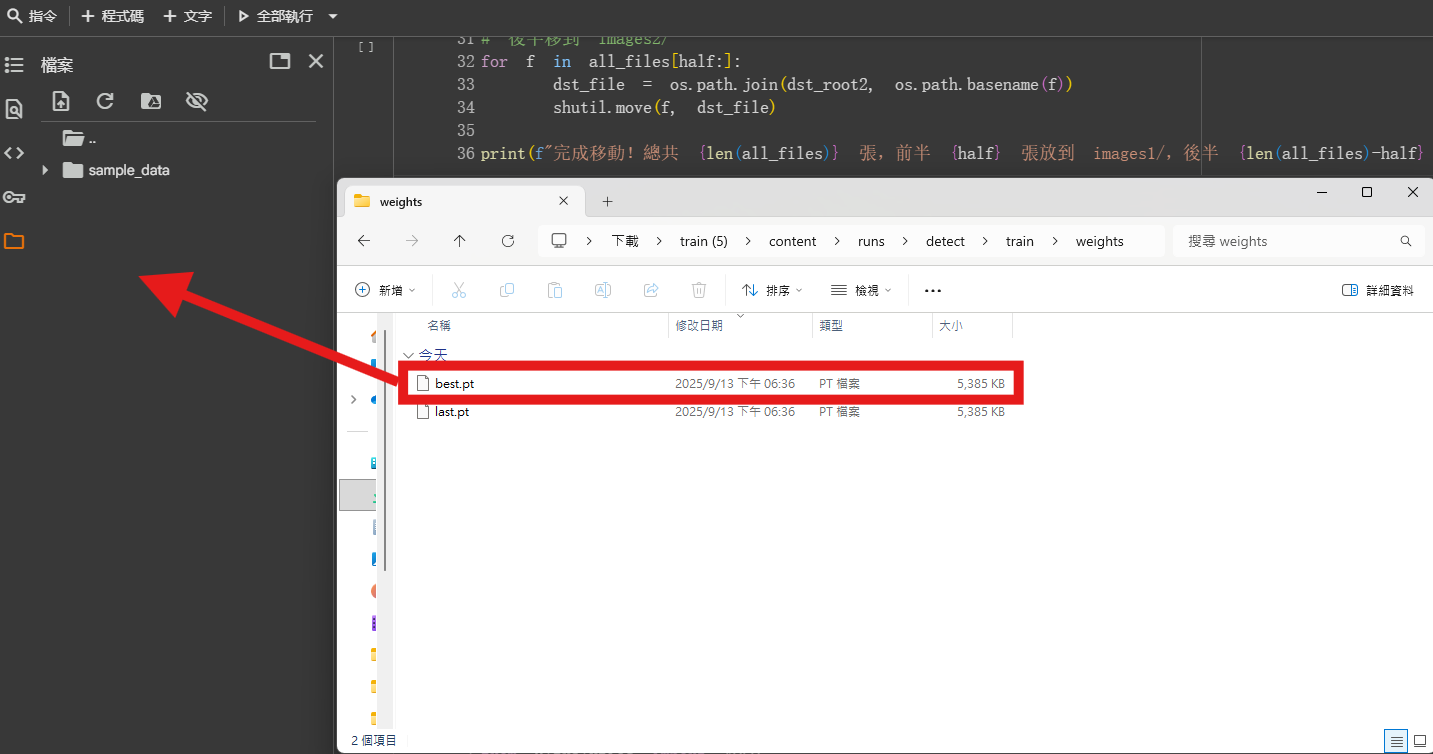

In [ ]:
!unzip -u "/content/train (1).zip" -d "/content/train/"

Archive:  /content/train (1).zip
   creating: /content/train/content/runs/detect/train/
  inflating: /content/train/content/runs/detect/train/val_batch0_labels.jpg  
  inflating: /content/train/content/runs/detect/train/val_batch2_labels.jpg  
   creating: /content/train/content/runs/detect/train/weights/
  inflating: /content/train/content/runs/detect/train/weights/last.pt  
  inflating: /content/train/content/runs/detect/train/weights/best.pt  
  inflating: /content/train/content/runs/detect/train/labels.jpg  
  inflating: /content/train/content/runs/detect/train/BoxF1_curve.png  
  inflating: /content/train/content/runs/detect/train/val_batch2_pred.jpg  
  inflating: /content/train/content/runs/detect/train/confusion_matrix_normalized.png  
  inflating: /content/train/content/runs/detect/train/train_batch1.jpg  
  inflating: /content/train/content/runs/detect/train/BoxR_curve.png  
  inflating: /content/train/content/runs/detect/train/train_batch4081.jpg  
  inflating: /content/trai

#=====================================================

#BLOCK 7

#使用訓練過模型進行預測前半部分圖片(執行時間3分鐘)

#=====================================================

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/best.pt')
results = model.predict(source="./datasets/test/images1/",
              save=True,
              imgsz=640,
              device=0
              )

Streaming output truncated to the last 5000 lines.
image 3313/8310 /content/datasets/test/images1/patient0060_0359.png: 640x640 (no detections), 14.4ms
image 3314/8310 /content/datasets/test/images1/patient0060_0360.png: 640x640 (no detections), 14.4ms
image 3315/8310 /content/datasets/test/images1/patient0060_0361.png: 640x640 (no detections), 12.1ms
image 3316/8310 /content/datasets/test/images1/patient0060_0362.png: 640x640 (no detections), 14.5ms
image 3317/8310 /content/datasets/test/images1/patient0060_0363.png: 640x640 (no detections), 12.5ms
image 3318/8310 /content/datasets/test/images1/patient0060_0364.png: 640x640 (no detections), 12.0ms
image 3319/8310 /content/datasets/test/images1/patient0060_0365.png: 640x640 (no detections), 20.0ms
image 3320/8310 /content/datasets/test/images1/patient0060_0366.png: 640x640 (no detections), 17.3ms
image 3321/8310 /content/datasets/test/images1/patient0060_0367.png: 640x640 (no detections), 11.9ms
image 3322/8310 /content/datasets/test/i

#predict資料夾內**有圖片代表預測完成**


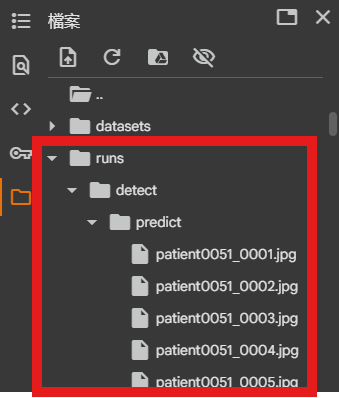

#=====================================================

#BLOCK 8

#其中一張預測結果

#=====================================================

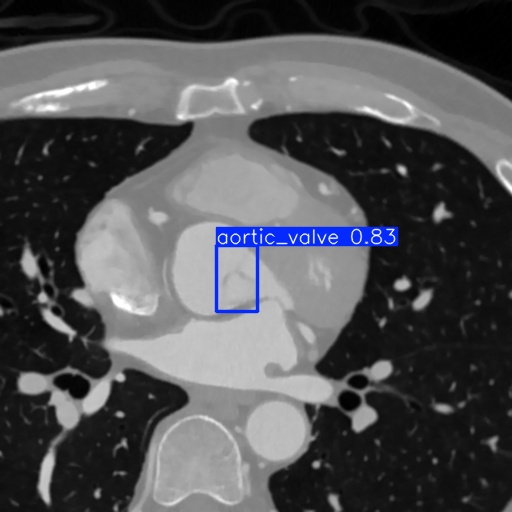

In [ ]:
from IPython.display import Image

Image(filename='/content/runs/detect/predict/patient0051_0260.jpg', height=600)

#=====================================================

#BLOCK 9

#預測數量

#=====================================================

In [ ]:
print(len(results))

8310


#=====================================================

#BLOCK 10

#取得預測結果的資訊

#想取得更多資訊可參考官方說明
#https://docs.ultralytics.com/zh/modes/predict/#boxes

#=====================================================

In [ ]:
print('預測類別 : ',results[260].boxes.cls[0].item())
print('預測信心分數 : ',results[260].boxes.conf[0].item())
print('預測框座標 : ',results[260].boxes.xyxy[0].tolist())

預測類別 :  0.0
預測信心分數 :  0.8318541646003723
預測框座標 :  [216.9983367919922, 245.821044921875, 258.9161682128906, 312.239501953125]


#=====================================================

#BLOCK 11

#將偵測框數值寫進.txt檔

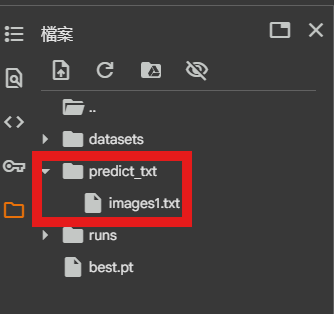

#=====================================================

In [ ]:
!mkdir ./predict_txt/
output_file = open('./predict_txt/images1.txt', 'w')
for i in range(len(results)):
    # 取得圖片檔名（不含副檔名）
    filename = results[i].path.split('/')[-1].split('.png')[0]

    # 取得預測框數量
    boxes = results[i].boxes
    box_num = len(boxes.cls.tolist())

    # 如果有預測框
    if box_num > 0:
        for j in range(box_num):
            # 提取資訊
            label = int(boxes.cls[j].item())  # 類別
            conf = boxes.conf[j].item()       # 信心度
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()  # 邊界框座標

            # 建立一行資料
            line = f"{filename} {label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}\n"
            output_file.write(line)

# 關閉輸出檔案
output_file.close()


#=====================================================

#BLOCK 12

#釋放記憶體

#因為Colab RAM不會自動釋放，所以透過程式釋放


#=====================================================

In [ ]:
import torch ,gc

# 刪除大型變數
del boxes,all_files,results
gc.collect()
torch.cuda.empty_cache()

#=====================================================

#BLOCK 13

#預測後半圖片(執行時間3分鐘)

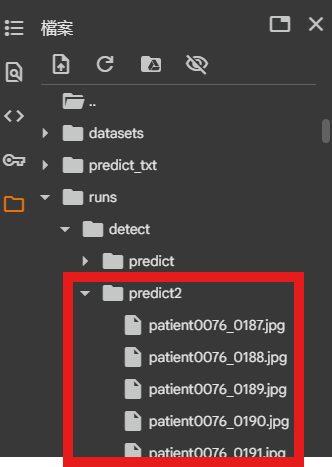

#=====================================================

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/best.pt')
results = model.predict(source="./datasets/test/images2/",
              save=True,
              imgsz=640,
              device=0
              )

Streaming output truncated to the last 5000 lines.
image 3313/8310 /content/datasets/test/images2/patient0086_0051.png: 640x640 (no detections), 20.4ms
image 3314/8310 /content/datasets/test/images2/patient0086_0052.png: 640x640 (no detections), 27.9ms
image 3315/8310 /content/datasets/test/images2/patient0086_0053.png: 640x640 (no detections), 31.2ms
image 3316/8310 /content/datasets/test/images2/patient0086_0054.png: 640x640 (no detections), 29.9ms
image 3317/8310 /content/datasets/test/images2/patient0086_0055.png: 640x640 (no detections), 26.9ms
image 3318/8310 /content/datasets/test/images2/patient0086_0056.png: 640x640 (no detections), 27.6ms
image 3319/8310 /content/datasets/test/images2/patient0086_0057.png: 640x640 (no detections), 24.9ms
image 3320/8310 /content/datasets/test/images2/patient0086_0058.png: 640x640 (no detections), 23.8ms
image 3321/8310 /content/datasets/test/images2/patient0086_0059.png: 640x640 (no detections), 21.5ms
image 3322/8310 /content/datasets/test/i

#=====================================================

#BLOCK 14

#將後半部分偵測框數值寫進.txt檔

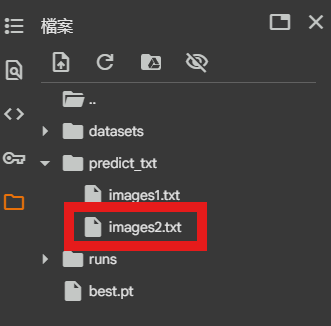

#=====================================================

In [ ]:
output_file = open('./predict_txt/images2.txt', 'w')
for i in range(len(results)):
    # 取得圖片檔名（不含副檔名）
    filename = results[i].path.split('/')[-1].split('.png')[0]

    # 取得預測框數量
    boxes = results[i].boxes
    box_num = len(boxes.cls.tolist())

    # 如果有預測框
    if box_num > 0:
        for j in range(box_num):
            # im提取資訊
            label = int(boxes.cls[j].item())  # 類別
            conf = boxes.conf[j].item()       # 信心度
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()  # 邊界框座標

            # 建立一行資料
            line = f"{filename} {label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}\n"
            output_file.write(line)

# 關閉輸出檔案
output_file.close()


#=====================================================

#BLOCK 15

#合併兩個.txt

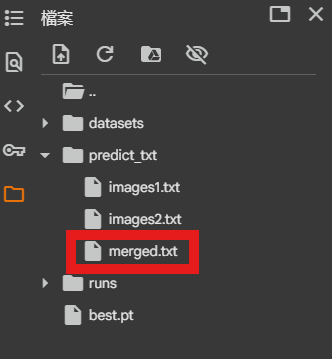

#=====================================================

In [ ]:
file1 = "./predict_txt/images1.txt"
file2 = "./predict_txt/images2.txt"
output = "./predict_txt/merged.txt"

with open(output, "w", encoding="utf-8") as fout:
    for f in [file1, file2]:
        if os.path.exists(f):
            with open(f, "r", encoding="utf-8") as fin:
                fout.writelines(fin.readlines())

print(f"合併完成 -> {output}")


合併完成 -> ./predict_txt/merged.txt


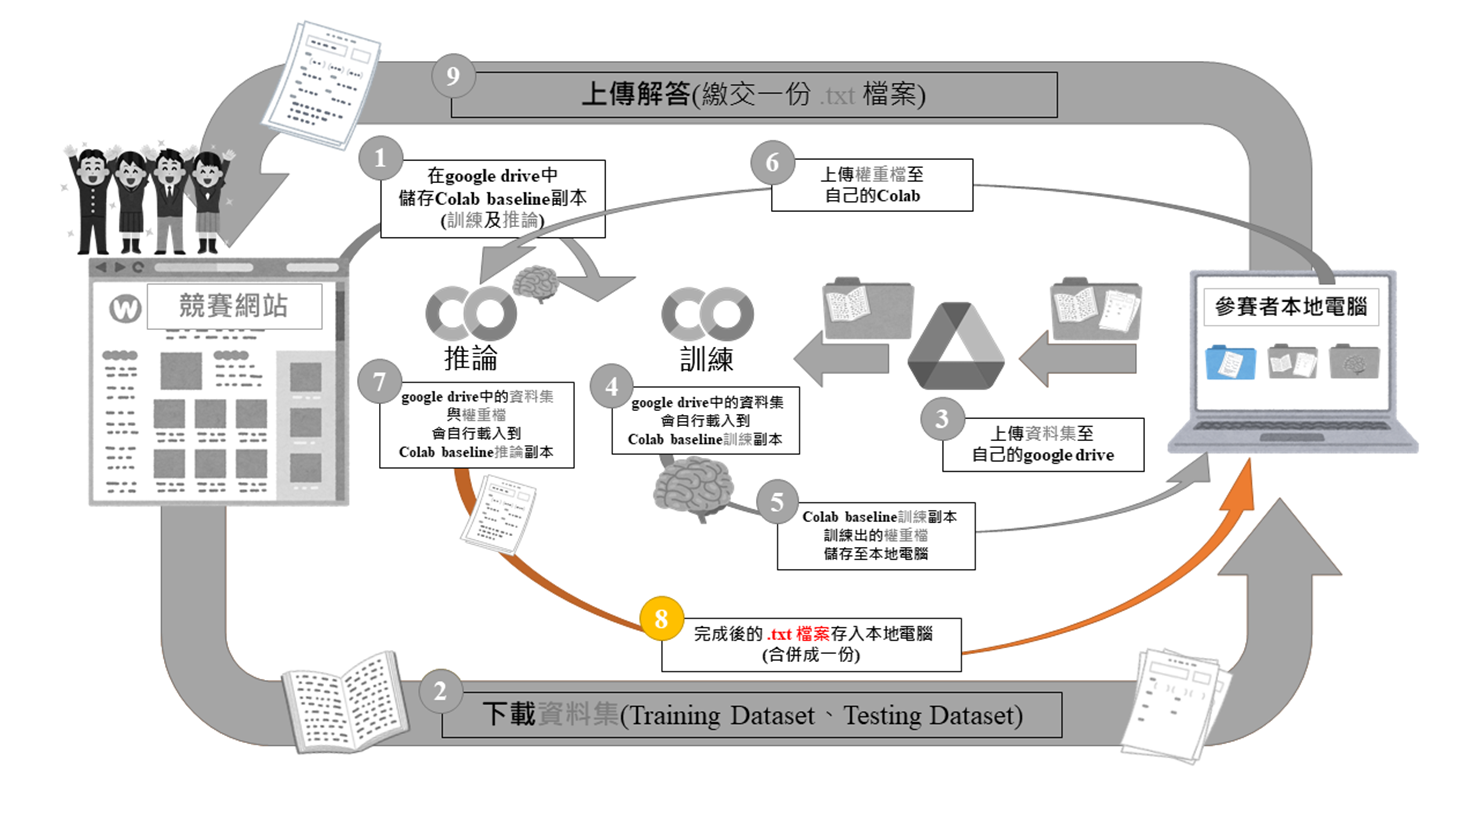

#=====================================================

#BLOCK 16

#下載競賽提交txt  image.png

#=====================================================

In [ ]:
from google.colab import files
files.download('/content/predict_txt/merged.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch ,gc

# 刪除大型變數
del boxes,all_files,results
gc.collect()
torch.cuda.empty_cache()

NameError: name 'boxes' is not defined